In [1]:
import os
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import pandas as pd
import preprocessing as prep
from model import perturbation
from model import BPNN as Predictor
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
import matplotlib.pyplot as plt
from random import sample

# wl_path = r'D:\20240412\wl.csv'
# select_path = r'D:\20240412\0412mean.csv'

# select = pd.read_csv(select_path,header=None).values
# raw_wl = pd.read_csv(wl_path,header=None).values.astype(np.float32)[12200-2048:12200]

# mean_spec = select[1:,1:]
# mean_spec = mean_spec[12200-2048:12200,:].T.astype(float)
# mean_lab = select[0,1:].astype(float)
# SKB = SelectKBest(f_regression, k=10)
# select_feat = SKB.fit_transform(mean_spec, mean_lab.ravel())
# index_feat = SKB.get_support()
# np.savetxt(r'D:/20240412/select_wl.csv',np.vstack((raw_wl[index_feat].reshape(-1),np.where(index_feat)[0])).T,delimiter=',',fmt='%s')
path = r'D:\20240412\multi_task\all.csv'
label_path = r'D:\20240412\multi_task\alllab.csv'
wl_path = r'D:\20240412\wl.csv'
save_path = r'D:\20240412\Rb_analysis\bpnn'

# super iter
num_feat = 10
random_seed = 2024  
batch_size = 128
lr = 1e-4
num_epochs = 3000
step_epoch = 10
new_feat_size = 100
mean_times = 20
new_feat = []
new_lab = []


######### read raw data ####################

raw_feat = pd.read_csv(path,header=None).values.astype(np.float32)[:,12195-4096:12195]
raw_label = pd.read_csv(label_path,header=None).values.astype(np.float32)[:,1]
raw_wl = pd.read_csv(wl_path,header=None).values.astype(np.float32)[12201-4096:12201]

In [2]:

######### make new feat ####################
unique_lab = np.unique(raw_label)
for labs in unique_lab:
    index = np.isin(raw_label,labs).reshape(-1)
    unique_feat = raw_feat[index,:]
    for _ in range(new_feat_size):
        new_feat.append(np.mean(unique_feat[sample(range(0,len(unique_feat[:,0]-1)),mean_times),:],axis = 0))
        new_lab.append(labs)

new_feat = np.array(new_feat)
new_lab = np.array(new_lab).reshape(-1,1)

# scaler = MinMaxScaler()
# new_feat = scaler.fit_transform(new_feat.T).T

# 取测试集
unique_lab = np.unique(new_lab)

select_lab = unique_lab[3]


In [3]:
wl_path = r'D:\20240412\wl.csv'

In [4]:
mean_feat = []
mean_lab = []
unique_lab = np.unique(raw_label)
for labs in unique_lab:
    index = np.isin(raw_label,labs).reshape(-1)
    mean_feat.append(raw_feat[index,:].mean(axis = 0))
    mean_lab.append(labs)
mean_feat = np.array(mean_feat)
mean_lab = np.array(mean_lab).reshape(-1,1)

In [5]:
raw_wl = pd.read_csv(wl_path,header=None).values.astype(np.float32)[12201-4096:12201]
SKB = SelectKBest(f_regression, k=10)
select_feat = SKB.fit_transform(mean_feat, mean_lab.ravel())
index_feat = SKB.get_support()

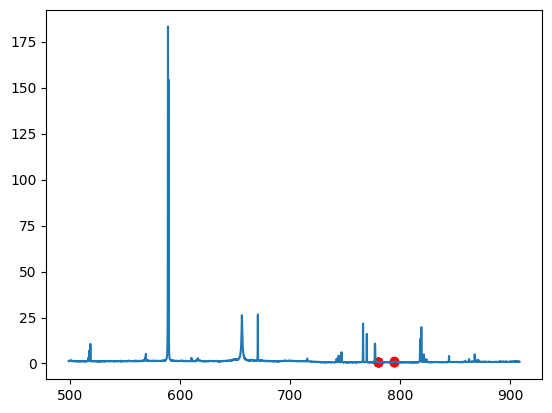

In [6]:
plt.figure(1)
plt.plot(raw_wl,mean_feat[0,:])
plt.scatter(raw_wl[index_feat],mean_feat[0,index_feat],c = 'r')

In [7]:

# np.savetxt(r'D:/20240412/select_wl.csv',np.vstack((raw_wl[index_feat].reshape(-1),np.where(index_feat)[0])).T,delimiter=',',fmt='%s')

Using GPU !


epoch: [2999/3000]: 100%|██████████| 10/10 [00:00<00:00, 213.34it/s]


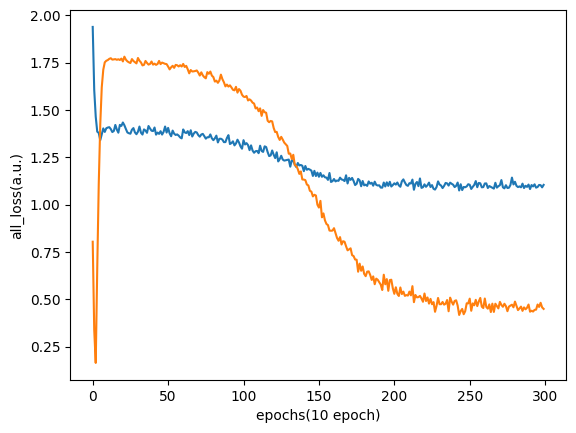

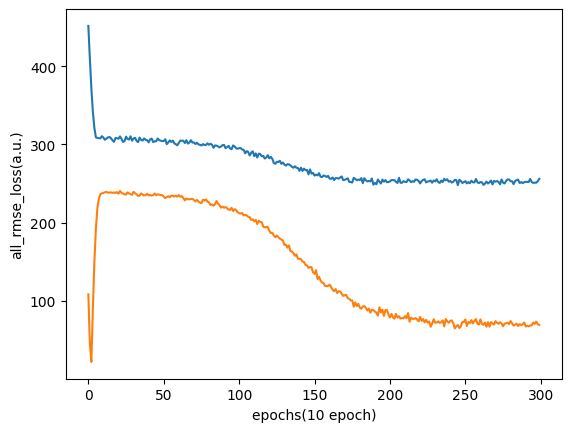

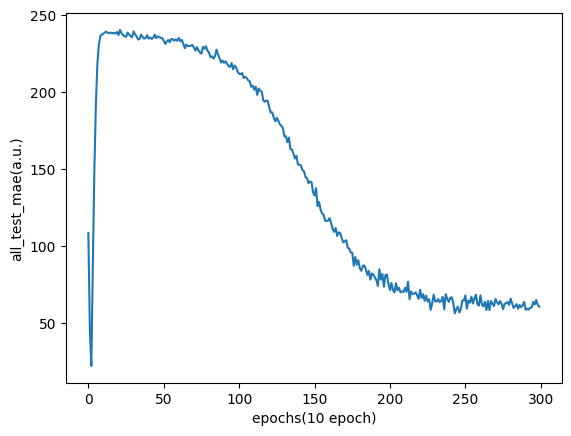

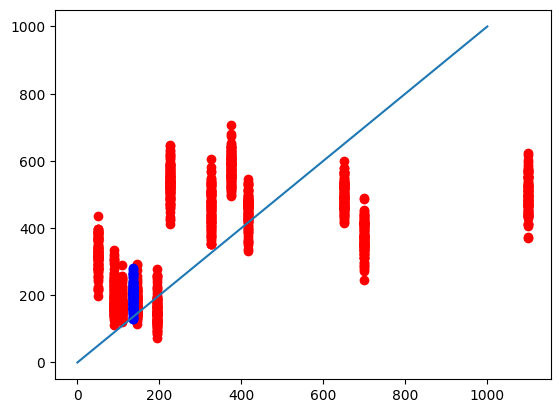

In [8]:

norm_feat = []


test_index = np.isin(new_lab,select_lab).reshape(-1)#-600 500 -1 50 

# # normalization
# feat_scaler = MinMaxScaler()
# lab_scaler = MinMaxScaler()

# for spec in range(len(new_feat[:,0])):
#     norm_feat.append(prep.Normalization(new_feat[spec,:]) )
# norm_feat = np.array(norm_feat) * 1000
norm_feat = new_feat * 1000
# norm_lab = lab_scaler.fit_transform(raw_label)

#buyong scaler

test_feat = norm_feat[test_index,:]
test_label = new_lab[test_index]
train_feat = norm_feat[~test_index,:]
train_label = new_lab[~test_index]

# random seeding

np.random.seed(random_seed)  
random_index = [i for i in range(len(train_label))]
np.random.shuffle(random_index)

train_feat = train_feat[random_index,:]
train_label = train_label[random_index]


# # import select
index_feat = pd.read_csv(r'D:\20240412\select_wl.csv',header=None).values[:,1].astype(int)


train_feat = train_feat[:, index_feat]
test_feat = test_feat[:, index_feat]

select_wl = raw_wl[index_feat]

# split train and test
# x_train,x_test,y_train,y_test = train_test_split(
#     norm_feat,norm_lab, test_size=0.2,shuffle = False)

x_train,x_test,y_train,y_test = train_feat,test_feat,train_label,test_label



train_data = torch.tensor(x_train, dtype=torch.float32)
train_label = torch.tensor(y_train, dtype=torch.float32)
train_dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_data, train_label), batch_size=batch_size, shuffle=True)

test_data = torch.tensor(x_test, dtype=torch.float32)
test_label = torch.tensor(y_test, dtype=torch.float32)
test_dataloader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(test_data, test_label), batch_size=batch_size, shuffle=True)
'''remember to set shuffle to False'''


# parameter define

if torch.cuda.is_available():
    device = 'cuda'
    print("Using GPU !")
else:
    device = 'cpu'

logdir = os.getcwd()

model = Predictor(num_feat,7,5,1)
perturb = perturbation(num_feat)
criterion = nn.MSELoss()


optimizer = torch.optim.Adam(model.parameters(), lr=lr)
perturb_optimizer = torch.optim.Adam(perturb.parameters(), lr=lr)


# variable define
all_sigma = []
all_net = []
mse_loss = []
train_loss = []
all_train_rmse = []
all_train_loss = []
all_test_rmse = []
all_test_mae = []
all_test_loss = []
train_pre_lab = []
test_pre_lab = []


## 模型训练
model.to(device)

    

for epoch in range(num_epochs):
    loop = tqdm(train_dataloader, total=len(train_dataloader))#loop 是使用 tqdm 创建的一个进度条，用于可视化每个轮次内部的循环进度。
    
    for x, y in loop:
        x = x.to(device)
        y = y.to(device)
        preds = model(x)
        loss = criterion(preds, y)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        loop.set_description('epoch: [%d/%d]' % (epoch, num_epochs))
    
    if epoch % step_epoch == 0: # 每step_epoch次epoch存一次数据
        model.eval()
        with torch.no_grad():
            sum_train_loss = 0
            sum_test_loss = 0
            sum_train_rmse = 0
            sum_test_rmse = 0
            sum_test_mae = 0
            for x, y in train_dataloader:
                x = x.to(device)
                y = y.to(device)
                preds = model(x)

                # 评估指标
                # y_denormalized = lab_scaler.inverse_transform(y.cpu())
                # preds_denormalized = lab_scaler.inverse_transform(preds.cpu())
                y_denormalized = y
                preds_denormalized = preds

                # 计算损失
                loss = torch.zeros_like(y_denormalized)  # 创建一个与 y 相同形状的张量来存储损失
                abs_loss_mask = (y_denormalized == 0.0)  # 布尔掩码，用于标记 y 中等于零的部分

                # 对等于零的部分使用绝对值损失
                loss[abs_loss_mask] = torch.abs(preds_denormalized[abs_loss_mask] - y_denormalized[abs_loss_mask])
                # 对不等于零的部分使用均方误差损失
                mse_loss_mask = ~abs_loss_mask  # 取反，用于标记 y 中不等于零的部分
                loss[mse_loss_mask] = torch.mean(torch.abs(preds_denormalized[mse_loss_mask] - y_denormalized[mse_loss_mask])) \
                    / y_denormalized[mse_loss_mask]
                train_loss = loss.mean()
                sum_train_loss = sum_train_loss + train_loss

                train_rmse = (np.sqrt(((preds_denormalized - y_denormalized).cpu() ** 2).mean())) # 数据存到cpu
                sum_train_rmse = sum_train_rmse + train_rmse

            for x_t, y_t in test_dataloader:
                x_t = x_t.to(device)
                y_t = y_t.to(device)
                preds = model(x_t)

                # 评估指标
                # y_denormalized = lab_scaler.inverse_transform(y_t.cpu())
                # preds_denormalized = lab_scaler.inverse_transform(preds.cpu())
                y_denormalized = y_t
                preds_denormalized = preds

                # 计算损失
                loss = torch.zeros_like(y_denormalized)  # 创建一个与 y 相同形状的张量来存储损失
                abs_loss_mask = (y_denormalized == 0.0)  # 布尔掩码，用于标记 y 中等于零的部分
                # 对等于零的部分使用绝对值损失
                loss[abs_loss_mask] = torch.abs(preds_denormalized[abs_loss_mask] - y_denormalized[abs_loss_mask])
                # 对不等于零的部分使用均方误差损失
                mse_loss_mask = ~abs_loss_mask  # 取反，用于标记 y 中不等于零的部分
                loss[mse_loss_mask] = torch.mean(torch.abs(preds_denormalized[mse_loss_mask] - y_denormalized[mse_loss_mask])) \
                    / y_denormalized[mse_loss_mask]
                test_loss = loss.mean()
                sum_test_loss = sum_test_loss + test_loss

                test_rmse = (np.sqrt(((preds_denormalized - y_denormalized).cpu() ** 2).mean()))
                sum_test_rmse = sum_test_rmse + test_rmse

                mae = np.absolute((preds_denormalized - y_denormalized).cpu()).mean()
                sum_test_mae = sum_test_mae + mae

            sum_train_loss = sum_train_loss.cpu().detach().numpy()#数据存到cpu= 直接用.item()也行
            sum_test_loss = sum_test_loss.cpu().detach().numpy()
            
            all_train_loss.append(sum_train_loss / len(train_dataloader))
            all_test_loss.append(sum_test_loss / len(test_dataloader))
            all_train_rmse.append(sum_train_rmse / len(train_dataloader))
            all_test_rmse.append(sum_test_rmse / len(test_dataloader))
            all_test_mae.append(sum_test_mae / len(test_dataloader))
            all_net.append(model)

            model.train()



# best epoch
sum_loss = [(all_train_loss[i] + all_test_loss[i]) for i in range(len(all_train_loss))]
best_epoch = sum_loss.index(min(sum_loss))

#    print('best_epoch=%d' % best_epoch*step_epoch)
if best_epoch == len(all_net):
    best_net = all_net[best_epoch-1]
else:
    best_net = all_net[best_epoch]

# save
# 所有参数 
all_train_loss1 = np.array(all_train_loss[best_epoch]).reshape(-1,1)
all_test_loss1 = np.array(all_test_loss[best_epoch]).reshape(-1,1)
all_train_rmse1 = np.array(all_train_rmse[best_epoch]).reshape(-1,1)
all_test_rmse1 = np.array(all_test_rmse[best_epoch]).reshape(-1,1)
all_test_mae1 = np.array(all_test_mae[best_epoch]).reshape(-1,1)

name_result = np.array(['all_train_loss','all_test_loss','all_train_rmse','all_test_rmse','all_test_mae']).reshape(-1,1).T
exp_result = np.hstack((all_train_loss1,all_test_loss1,all_train_rmse1,all_test_rmse1,all_test_mae1))
result = np.vstack((name_result,exp_result))

torch.save(best_net,save_path + '//' + str(select_lab) + 'best_net.pth')
np.savetxt(save_path + '//' + str(select_lab) + 'result.csv',result,delimiter=',',fmt='%s')

# perturbation train

# best_net.cpu()
# best_net.eval()

# perturb.cpu()
# another_epoch = int(num_epochs)

# test_dataloader = torch.utils.data.DataLoader(
#     torch.utils.data.TensorDataset(test_data, test_label), batch_size=32, shuffle=False)

# for epochs in range(another_epoch):
#     loop = tqdm(test_dataloader, total=len(test_dataloader))
#     for x, y in loop:
#         x = x.cpu()
#         pp,pm,sigma = perturb(x)
#         sigma = sigma.cpu().detach()#记得换个位置存
#         p = best_net(x)
#         pp = best_net(pp)
#         pm = best_net(pm)
#         pp = torch.abs(pp - p)
#         pm = torch.abs(pm - p)
#         const = torch.full([pp.size()[0],1],torch.max(p).item())
#         const_0 = torch.full([pp.size()[0],1],torch.min(p).item())

#         l1 = criterion(pp,const_0)
#         l2 = criterion(pm,const)
#         l3 = criterion(sigma,torch.zeros(num_feat))

#         loss = l1 + l2 + l3


#         perturb_optimizer.zero_grad()
#         loss.backward()

#         perturb_optimizer.step()
        
# #        loop.set_description('epoch: [%d/%d]' % (epoch, another_epoch))

#     if epochs % step_epoch == 0: # 每step_epoch次epoch存一次数据
#         save_sigma = sigma.clone().numpy()
#         all_sigma.append(save_sigma)
        
# np.savetxt(save_path + '//' + str(select_lab) + 'sigma.csv',all_sigma,delimiter=',',fmt='%s')

# # draw

cutoff = 0
plt.figure(1)
plt.plot(all_train_loss[cutoff:], label='train_loss')
plt.plot(all_test_loss[cutoff:], label='test_loss')
plt.xlabel("epochs(10 epoch)")
plt.ylabel("all_loss(a.u.)")
plt.show()

plt.figure(2)
plt.plot(all_train_rmse[cutoff:], label='train_rmse')
plt.plot(all_test_rmse[cutoff:], label='test_rmse')
plt.xlabel("epochs(10 epoch)")
plt.ylabel("all_rmse_loss(a.u.)")
plt.show()

plt.figure(3)
plt.plot(all_test_mae[cutoff:], label='mae')
plt.xlabel("epochs(10 epoch)")
plt.ylabel("all_test_mae(a.u.)")
plt.show()

plt.figure(4)
x = y = [0,1000]
plt.plot(x,y)

best_net.cpu()
best_net.eval()


# plt.scatter(lab_scaler.inverse_transform(train_label), 
#             lab_scaler.inverse_transform(best_net(train_data).detach().numpy()),
#             label="train set",c = 'r')
# plt.scatter(lab_scaler.inverse_transform(test_label), 
#             lab_scaler.inverse_transform(best_net(test_data).detach().numpy()),
#                 label="test set",c = 'b')
plt.scatter(train_label, 
            best_net(train_data.to(device).cpu()).cpu().detach().numpy(),
            label="train set",c = 'r')
plt.scatter(test_label, 
            best_net(test_data.to(device).cpu()).cpu().detach().numpy(),
                label="test set",c = 'b')

plt.show()

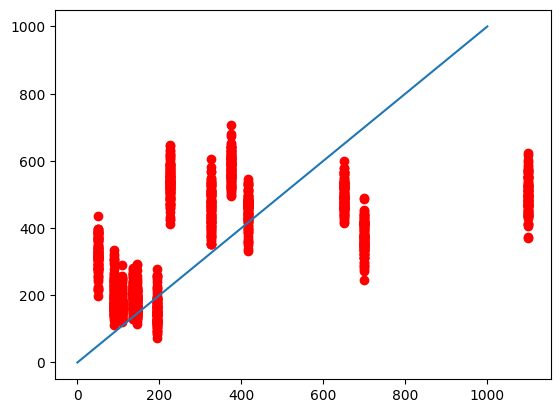

In [9]:
plt.scatter(train_label, 
            best_net(train_data.to(device).cpu()).cpu().detach().numpy(),
            label="train set",c = 'r')
plt.scatter(test_label, 
            best_net(test_data.to(device).cpu()).cpu().detach().numpy(),
                label="test set",c = 'r')
x = y = [0,1000]
plt.plot(x,y)

plt.show()

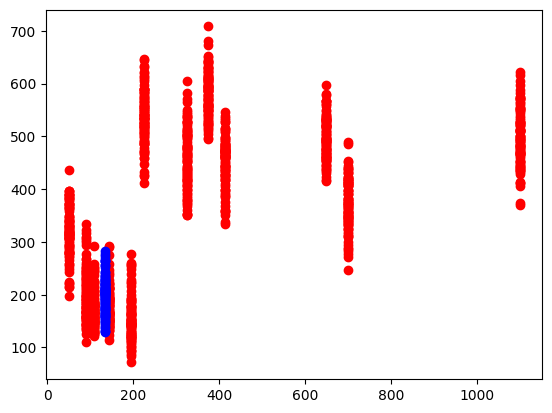

In [10]:
plt.scatter(train_label, 
            best_net(train_data.to(device).cpu()).cpu().detach().numpy(),
            label="train set",c = 'r')
plt.scatter(test_label, 
            best_net(test_data.to(device).cpu()).cpu().detach().numpy(),
                label="test set",c = 'b')

In [11]:
# save_Y = np.hstack((np.vstack((train_label,test_label)),
#                np.vstack((best_net(train_data.to(device).cpu()).cpu().detach().numpy(),
#                           best_net(test_data.to(device).cpu()).cpu().detach().numpy()))))

# np.savetxt(save_path + '//' + 'Y_predict_all.csv',save_Y,delimiter=',',fmt='%s')